# 🧪 실험 2: Transfer Learning + 데이터 증강

---

## 이 모델이 하는 일

실험 1과 동일하게 **반려동물 피부 사진 → 7가지 질환 분류**를 수행합니다.

```
📸 반려동물 피부 사진 입력
        ↓
    [EfficientNetB0 + 커스텀 분류층]
        ↓
    A4 농포/여드름 : 91.7%  ← 예측 결과
```

## 실험 1과 무엇이 다른가?

| 항목 | 실험 1 (Baseline) | 실험 2 (이번 실험) |
|------|------------------|------------------|
| **모델** | Conv2D 4블록 직접 설계 | **EfficientNetB0** (ImageNet 사전학습) |
| **데이터 증강** | 없음 (정규화만) | **회전, 반전, 밝기, 줌 등 적용** |
| **Class Weight** | 없음 | 없음 |
| **핵심 질문** | CNN으로 분류가 되는가? | **사전학습 + 증강으로 얼마나 좋아지는가?** |

## Transfer Learning이란?

ImageNet(1400만 장, 1000클래스)으로 이미 학습된 모델의 **시각적 특징 추출 능력을 가져와서** 우리 데이터(피부 질환)에 맞게 **분류층만 새로 학습**하는 기법입니다.

```
[ImageNet으로 학습된 EfficientNetB0]    ← 엣지, 질감, 형태 등 범용 특징 이미 학습됨
        ↓ (가중치 고정 = freeze)
[우리가 새로 붙인 분류층]               ← 피부 질환 7클래스에 맞게 새로 학습
        ↓
    A1~A7 확률 출력
```

**장점**: 적은 데이터로도 높은 성능 달성 가능. 직접 설계보다 훨씬 강력한 특징 추출.

## 데이터 증강이란?

원본 이미지를 회전, 반전, 밝기 조절 등으로 **변형하여 다양한 버전을 만드는 기법**입니다.  
데이터 수를 실질적으로 늘려 **과적합을 방지**하고 **일반화 성능을 향상**시킵니다.

| 증강 기법 | 설정 | 이유 |
|----------|------|------|
| horizontal_flip | True | 피부 병변은 좌우 방향 무관 |
| rotation_range | 30° | 카메라 각도 다양성 반영 |
| brightness_range | [0.8, 1.2] | 촬영 환경(조명) 차이 극복 |
| zoom_range | 0.1 | 병변 크기 다양성 반영 |
| width/height_shift | 0.1 | 병변 위치 다양성 반영 |

## 기대 효과

실험 1(직접 설계 CNN)보다 **확실한 성능 향상** 예상 (75~85%+)

---


## 0. 라이브러리 임포트 및 설정

실험 1과 동일한 라이브러리 + **EfficientNetB0**를 추가로 임포트합니다.

| 추가 라이브러리 | 역할 |
|---------------|------|
| `EfficientNetB0` | ImageNet 사전학습된 경량 CNN 모델. 정확도 대비 파라미터 수가 적어 효율적 |
| `keras.Model` | Sequential 대신 함수형 API 사용 (사전학습 모델 연결에 필요) |


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

# 실험 2 핵심: EfficientNetB0 사전학습 모델 임포트
from keras.applications import EfficientNetB0

# 함수형 API용 (Sequential 대신 사용)
from keras.models import Model

from keras.layers import (
    Dense,                 # 완전연결층: 최종 분류 수행
    Dropout,               # 드롭아웃: 과적합 방지
    GlobalAveragePooling2D,# 전역 평균 풀링: 특징맵 → 벡터 압축
    Input                  # 입력층 정의 (함수형 API에서 사용)
)

from keras.callbacks import (
    EarlyStopping,         # 조기 종료: val_loss 개선 없으면 학습 중단
    ModelCheckpoint,       # 체크포인트: 최고 성능 모델 자동 저장
    ReduceLROnPlateau      # 학습률 감소: val_loss 정체 시 lr 감소
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"TensorFlow 버전: {tf.__version__}")
print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 버전: 2.21.0
GPU 사용 가능: False


In [28]:
# i7-10700K: 8코어 / 16스레드 최적화
tf.config.threading.set_intra_op_parallelism_threads(16)  # 연산 내부 병렬 스레드
tf.config.threading.set_inter_op_parallelism_threads(8)   # 연산 간 병렬 스레드

print(f"intra threads: {tf.config.threading.get_intra_op_parallelism_threads()}")
print(f"inter threads: {tf.config.threading.get_inter_op_parallelism_threads()}")


intra threads: 16
inter threads: 8


## 1. 경로 설정 및 데이터 로딩

실험 1과 동일한 데이터를 사용하되, **동일한 train/val/test 분할**을 유지합니다.  
실험 간 비교가 공정하려면 **같은 데이터 분할**을 써야 합니다.


In [29]:
# 경로 설정 (models/ 폴더 기준)
ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
FIG_DIR   = ROOT / 'outputs' / 'figures'
MODEL_DIR = ROOT / 'models'

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 루트  : {ROOT.resolve()}")
print(f"CSV 경로      : {PROCESSED.resolve()}")
print(f"그래프 저장    : {FIG_DIR.resolve()}")
print(f"모델 저장      : {MODEL_DIR.resolve()}")


프로젝트 루트  : D:\SAG
CSV 경로      : D:\SAG\data\processed
그래프 저장    : D:\SAG\outputs\figures
모델 저장      : D:\SAG\models


In [30]:
# CSV 로딩 + train/val/test 분리
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')
target_col = 'img_path'

df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f"✅ 데이터 로드 완료")
print(f"  train : {len(df_train):,}장")
print(f"  val   : {len(df_val):,}장")
print(f"  test  : {len(df_test):,}장")


✅ 데이터 로드 완료
  train : 24,492장
  val   : 5,249장
  test  : 5,246장


## 2. 하이퍼파라미터 설정

실험 1과 대부분 동일하되, **이미지 크기와 학습률을 변경**합니다.

| 파라미터 | 실험 1 | 실험 2 | 변경 이유 |
|---------|--------|--------|----------|
| **IMG_SIZE** | **(128, 128)** | **(128, 128)** | EfficientNetB0은 32×32 이상 지원, CPU 환경에서 128이 속도-정확도 균형에 적합 |
| BATCH_SIZE | 64 | 64 | 동일 |
| EPOCHS | 20 | 30 | EarlyStopping이 실제 종료 결정 |
| **LEARNING_RATE** | **0.001** | **0.0001** | 사전학습 모델은 이미 좋은 가중치를 갖고 있어서, 큰 학습률로 급격히 바꾸면 오히려 성능 저하 |
| **LR_FINETUNE** | **—** | **1e-5** | Phase 2 fine-tuning: 사전학습 가중치 보존을 위해 더 작은 학습률 |


In [31]:
IMG_SIZE      = (128, 128)
BATCH_SIZE    = 64
EPOCHS        = 30
NUM_CLASSES   = 7
LEARNING_RATE = 0.0001
LR_FINETUNE   = 1e-5

print(f"이미지 크기  : {IMG_SIZE}")
print(f"배치 크기    : {BATCH_SIZE}")
print(f"최대 에폭    : {EPOCHS}")
print(f"클래스 수    : {NUM_CLASSES}")
print(f"학습률       : {LEARNING_RATE}")
print(f"Fine-tune LR : {LR_FINETUNE}")


이미지 크기  : (128, 128)
배치 크기    : 64
최대 에폭    : 30
클래스 수    : 7
학습률       : 0.0001
Fine-tune LR : 1e-05


## 3. 데이터 Generator 생성 (증강 적용)

실험 1과의 **핵심 차이점**: Train 데이터에 **데이터 증강(Augmentation)** 을 적용합니다.

| 파라미터 | 값 | 효과 |
|---------|-----|------|
| `horizontal_flip` | True | 좌우 반전 → 방향 다양성 |
| `rotation_range` | 30 | ±30도 회전 → 각도 다양성 |
| `brightness_range` | [0.8, 1.2] | 밝기 변화 → 조명 다양성 |
| `zoom_range` | 0.1 | 10% 확대/축소 → 크기 다양성 |
| `width_shift_range` | 0.1 | 좌우 이동 → 위치 다양성 |
| `height_shift_range` | 0.1 | 상하 이동 → 위치 다양성 |
| `fill_mode` | 'nearest' | 빈 영역을 가장 가까운 픽셀로 채움 |

> 💡 Val/Test는 증강하지 않습니다 — 원본으로 평가해야 공정합니다.


In [32]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=30,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator()

print("✅ ImageDataGenerator 정의 완료")
print("  Train: 정규화 + 증강 7종 적용")
print("  Val/Test: 정규화만 적용")


✅ ImageDataGenerator 정의 완료
  Train: 정규화 + 증강 7종 적용
  Val/Test: 정규화만 적용


### 3-1. flow_from_dataframe — Generator 생성

실험 1과 동일한 구조이지만, `train_datagen`에 증강이 적용되어 있으므로 **매 에폭마다 다른 변형 이미지**가 모델에 전달됩니다.


In [33]:
# Train Generator (증강 적용됨)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Validation Generator (증강 없음)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test Generator (증강 없음)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Generator 생성 완료")
print(f"클래스 인덱스: {train_generator.class_indices}")
print(f"Train 배치 수: {len(train_generator)}")
print(f"Val 배치 수  : {len(val_generator)}")
print(f"Test 배치 수 : {len(test_generator)}")


Found 24492 validated image filenames belonging to 7 classes.
Found 5249 validated image filenames belonging to 7 classes.
Found 5246 validated image filenames belonging to 7 classes.

✅ Generator 생성 완료
클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}
Train 배치 수: 383
Val 배치 수  : 83
Test 배치 수 : 82


## 4. EfficientNetB0 + 커스텀 분류층 모델 정의

### 실험 1 vs 실험 2 모델 구조 비교

```
[실험 1: 직접 설계]              [실험 2: Transfer Learning]

입력 (128×128×3)                 입력 (224×224×3)
    ↓                               ↓
Conv2D(32) → BN → Pool          ┌─────────────────────┐
    ↓                           │  EfficientNetB0      │
Conv2D(64) → BN → Pool          │  (ImageNet 사전학습)  │
    ↓                           │  ⚡ 가중치 고정       │
Conv2D(128) → BN → Pool         │  (freeze = 학습 안함) │
    ↓                           └─────────────────────┘
Conv2D(256) → BN → Pool             ↓
    ↓                           GlobalAveragePooling2D
GlobalAveragePooling2D              ↓
    ↓                           Dense(256) + Dropout(0.3)
Dense(256) + Dropout(0.5)           ↓
    ↓                           Dense(7, softmax)
Dense(7, softmax)                   ↓
    ↓                           출력: [A1~A7 확률]
출력: [A1~A7 확률]
```

### EfficientNetB0을 선택한 이유

| 모델 | 파라미터 수 | ImageNet 정확도 | 특징 |
|------|-----------|----------------|------|
| ResNet50 | 25.6M | 76.0% | 무거움, 클래식 |
| **EfficientNetB0** | **5.3M** | **77.1%** | **가벼우면서 정확도 높음** |
| VGG16 | 138M | 71.3% | 매우 무거움 |

→ 미니 프로젝트에 가장 적합: **가볍고, 정확하고, 학습 빠름**

### Freeze(동결)란?

EfficientNetB0의 가중치를 **고정(freeze)**하여 학습하지 않습니다.  
ImageNet에서 배운 범용 특징(엣지, 질감, 형태)은 이미 충분히 좋기 때문에,  
**우리가 새로 붙인 분류층(Dense)만 학습**하여 피부 질환에 맞게 조정합니다.

In [34]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

print(f"EfficientNetB0 로드 완료")
print(f"  입력 크기: {IMG_SIZE}")
print(f"  전체 레이어 수: {len(base_model.layers)}")
print(f"  학습 가능 파라미터: {sum(p.numpy().size for p in base_model.trainable_weights):,}")
print(f"  고정된 파라미터: {sum(p.numpy().size for p in base_model.non_trainable_weights):,}")


EfficientNetB0 로드 완료
  입력 크기: (128, 128)
  전체 레이어 수: 238
  학습 가능 파라미터: 0
  고정된 파라미터: 4,049,571


### 4-1. 커스텀 분류층 연결

EfficientNetB0 위에 **우리만의 분류층**을 연결합니다.  
함수형 API(Functional API)를 사용하여 사전학습 모델과 새 레이어를 연결합니다.


In [35]:
inputs = Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)
model = Model(inputs=inputs, outputs=outputs)

print("전체 모델 구성 완료")


전체 모델 구성 완료


## 5. 모델 컴파일

실험 1과 동일한 설정이지만, **학습률만 0.0001**로 낮춰서 사전학습 모델을 미세 조정합니다.


In [36]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # Adam (lr=0.0001)
    loss='categorical_crossentropy',    # 다중 클래스 분류 손실 함수
    metrics=['accuracy']                # 정확도 모니터링
)

# 모델 구조 요약
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. 콜백(Callbacks) 설정

실험 1과 동일한 구조이며, **저장 경로만 `exp2_transfer.h5`로 변경**합니다.


In [37]:
callbacks = [
    # val_loss가 5 에폭 연속 개선 안 되면 학습 중단
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # 최고 성능 모델을 exp2_transfer.h5로 저장
    ModelCheckpoint(
        filepath=str(MODEL_DIR / 'exp2_transfer.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # val_loss 정체 시 학습률 절반으로 감소 (patience=3 < EarlyStopping=5 이므로 정상 발동)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,           # 최소 학습률 (실험 1보다 더 작게)
        verbose=1
    )
]

print("✅ 콜백 설정 완료")
print(f"  모델 저장 경로: {MODEL_DIR / 'exp2_transfer.h5'}")

✅ 콜백 설정 완료
  모델 저장 경로: ..\models\exp2_transfer.h5


## 7. 모델 학습

EfficientNetB0의 가중치는 고정되어 있으므로, **새로 붙인 분류층(Dense)만 학습**됩니다.  
전체 파라미터 중 학습되는 부분이 적어 **실험 1보다 학습이 빠릅니다**.


In [38]:
print("=" * 50)
print("🚀 실험 2: Transfer Learning + 증강 학습 시작")
print("=" * 50)

history = model.fit(
    train_generator,                # 증강 적용된 훈련 데이터
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ 학습 완료!")
print(f"   실제 학습 에폭 수: {len(history.history['loss'])}회")


🚀 실험 2: Transfer Learning + 증강 학습 시작
Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.1986 - loss: 1.9540
Epoch 1: val_loss improved from None to 1.79517, saving model to ..\models\exp2_transfer.h5



Epoch 1: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - accuracy: 0.2277 - loss: 1.9017 - val_accuracy: 0.2995 - val_loss: 1.7952 - learning_rate: 1.0000e-04
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.2810 - loss: 1.8161
Epoch 2: val_loss improved from 1.79517 to 1.74696, saving model to ..\models\exp2_transfer.h5



Epoch 2: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.2856 - loss: 1.8034 - val_accuracy: 0.3250 - val_loss: 1.7470 - learning_rate: 1.0000e-04
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.3123 - loss: 1.7668
Epoch 3: val_loss improved from 1.74696 to 1.71288, saving model to ..\models\exp2_transfer.h5



Epoch 3: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 379s 990ms/step - accuracy: 0.3141 - loss: 1.7612 - val_accuracy: 0.3387 - val_loss: 1.7129 - learning_rate: 1.0000e-04
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.3283 - loss: 1.7320
Epoch 4: val_loss improved from 1.71288 to 1.69340, saving model to ..\models\exp2_transfer.h5



Epoch 4: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.3306 - loss: 1.7265 - val_accuracy: 0.3462 - val_loss: 1.6934 - learning_rate: 1.0000e-04
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.3443 - loss: 1.6992
Epoch 5: val_loss improved from 1.69340 to 1.67134, saving model to ..\models\exp2_transfer.h5


...


Epoch 26: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.4522 - loss: 1.4606 - val_accuracy: 0.4269 - val_loss: 1.5171 - learning_rate: 1.0000e-04
Epoch 27/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.4595 - loss: 1.4542
Epoch 27: val_loss improved from 1.51709 to 1.51520, saving model to ..\models\exp2_transfer.h5



Epoch 27: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 376s 982ms/step - accuracy: 0.4535 - loss: 1.4579 - val_accuracy: 0.4262 - val_loss: 1.5152 - learning_rate: 1.0000e-04
Epoch 28/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.4618 - loss: 1.4467
Epoch 28: val_loss improved from 1.51520 to 1.50977, saving model to ..\models\exp2_transfer.h5



Epoch 28: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 375s 980ms/step - accuracy: 0.4609 - loss: 1.4454 - val_accuracy: 0.4330 - val_loss: 1.5098 - learning_rate: 1.0000e-04
Epoch 29/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.4656 - loss: 1.4347
Epoch 29: val_loss improved from 1.50977 to 1.50733, saving model to ..\models\exp2_transfer.h5



Epoch 29: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 376s 981ms/step - accuracy: 0.4641 - loss: 1.4383 - val_accuracy: 0.4306 - val_loss: 1.5073 - learning_rate: 1.0000e-04
Epoch 30/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.4730 - loss: 1.4250
Epoch 30: val_loss improved from 1.50733 to 1.50513, saving model to ..\models\exp2_transfer.h5



Epoch 30: finished saving model to ..\models\exp2_transfer.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 377s 984ms/step - accuracy: 0.4697 - loss: 1.4314 - val_accuracy: 0.4290 - val_loss: 1.5051 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.

✅ 학습 완료!
   실제 학습 에폭 수: 30회


## 7-2. Phase 2: Fine-tuning (상위 레이어 언프리즈)

Phase 1에서 head가 수렴한 후, **EfficientNetB0 상위 30개 레이어를 언프리즈**하여 미세 조정합니다.

| 단계 | 학습 대상 | 학습률 |
|------|----------|--------|
| Phase 1 | Dense head만 | 0.0001 |
| **Phase 2** | **EfficientNetB0 상위 30층 + head** | **1e-5** |

> 하위 레이어(엣지/질감)는 그대로 유지, 상위 레이어만 피부 질환 패턴에 맞게 조정


In [39]:
# Phase 2: 상위 30개 레이어 언프리즈 후 미세조정
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(p.numpy().size for p in model.trainable_weights)
print(f"Fine-tuning 학습 가능 파라미터: {trainable_count:,}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath=str(MODEL_DIR / "exp2_transfer_finetuned.keras"),
        monitor="val_loss", save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-8, verbose=1)
]

print("Phase 2 Fine-tuning 시작")
history_ft = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_ft,
    verbose=1
)

print(f"Fine-tuning 완료! 에폭 수: {len(history_ft.history['loss'])}")


Fine-tuning 학습 가능 파라미터: 1,825,895
Phase 2 Fine-tuning 시작
Epoch 1/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.3208 - loss: 1.7689
Epoch 1: val_loss improved from None to 1.68198, saving model to ..\models\exp2_transfer_finetuned.keras

Epoch 1: finished saving model to ..\models\exp2_transfer_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.3309 - loss: 1.7424 - val_accuracy: 0.3568 - val_loss: 1.6820 - learning_rate: 1.0000e-05
Epoch 2/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.3587 - loss: 1.6628
Epoch 2: val_loss improved from 1.68198 to 1.65247, saving model to ..\models\exp2_transfer_finetuned.keras

Epoch 2: finished saving model to ..\models\exp2_transfer_finetuned.keras
383/383 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.3637 - loss: 1.6589 - val_accuracy: 0.3673 - val_loss: 1.6525 - learning_rate: 1.0000e-05
Epoch 3/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.3782 - loss: 1.6243
Epoch 3: val_loss improv

## 8. 학습 곡선 시각화

실험 1과 비교하여:
- **Val Loss가 더 낮은지** → 일반화 성능 향상
- **Train-Val 격차가 줄었는지** → 증강으로 과적합 완화


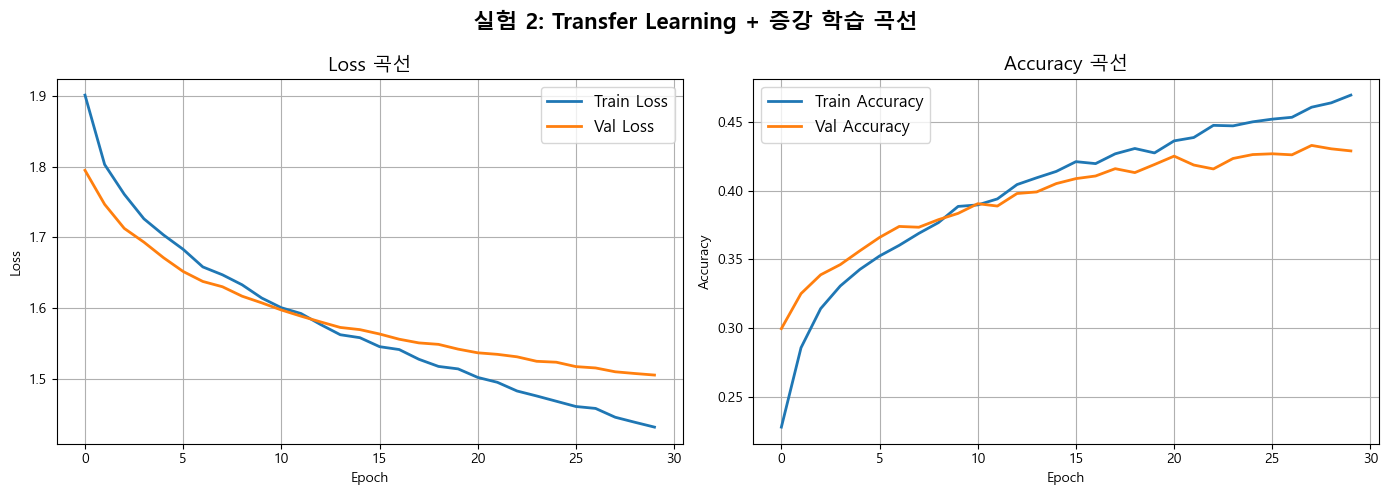

📊 학습 곡선 저장 → ..\outputs\figures\exp2_learning_curve.png


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Loss 곡선', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True)

# Accuracy 곡선
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy 곡선', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True)

plt.suptitle('실험 2: Transfer Learning + 증강 학습 곡선', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig(FIG_DIR / 'exp2_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 학습 곡선 저장 → {FIG_DIR / 'exp2_learning_curve.png'}")


## 9. 테스트 데이터 평가

학습에 사용하지 않은 **테스트 데이터(5,250장)**로 최종 성능을 측정합니다.


In [41]:
print("=" * 50)
print("📝 테스트 데이터 평가")
print("=" * 50)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"\n테스트 Loss    : {test_loss:.4f}")
print(f"테스트 Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")


📝 테스트 데이터 평가
82/82 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.4150 - loss: 1.5481

테스트 Loss    : 1.5481
테스트 Accuracy: 0.4150 (41.5%)


## 10. 상세 평가 — Classification Report

클래스별 Precision, Recall, F1-Score를 확인합니다.  
실험 1 대비 **어떤 클래스의 성능이 얼마나 올랐는지** 비교 포인트입니다.


In [42]:
# 테스트 데이터 전체 예측
y_pred_proba = model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes

# 클래스명 매핑
class_names = list(train_generator.class_indices.keys())
LESION_MAP = {
    'A1': 'A1 구진/플라크',
    'A2': 'A2 비듬/각질',
    'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름',
    'A5': 'A5 미란/궤양',
    'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)'
}
class_labels = [LESION_MAP[c] for c in class_names]

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))


82/82 ━━━━━━━━━━━━━━━━━━━━ 58s 694ms/step
=== Classification Report ===
              precision    recall  f1-score   support

   A1 구진/플라크       0.38      0.33      0.35       749
    A2 비듬/각질       0.33      0.38      0.35       750
   A3 태선화/색소       0.35      0.45      0.39       750
   A4 농포/여드름       0.42      0.37      0.39       749
    A5 미란/궤양       0.51      0.54      0.52       750
    A6 결절/종괴       0.50      0.49      0.49       750
  A7 무증상(정상)       0.45      0.35      0.40       748

    accuracy                           0.41      5246
   macro avg       0.42      0.41      0.41      5246
weighted avg       0.42      0.41      0.41      5246



### 10-1. Confusion Matrix (혼동 행렬)

실험 1 대비 **대각선 값이 커졌는지** (맞춘 수 증가) 비교해보세요.


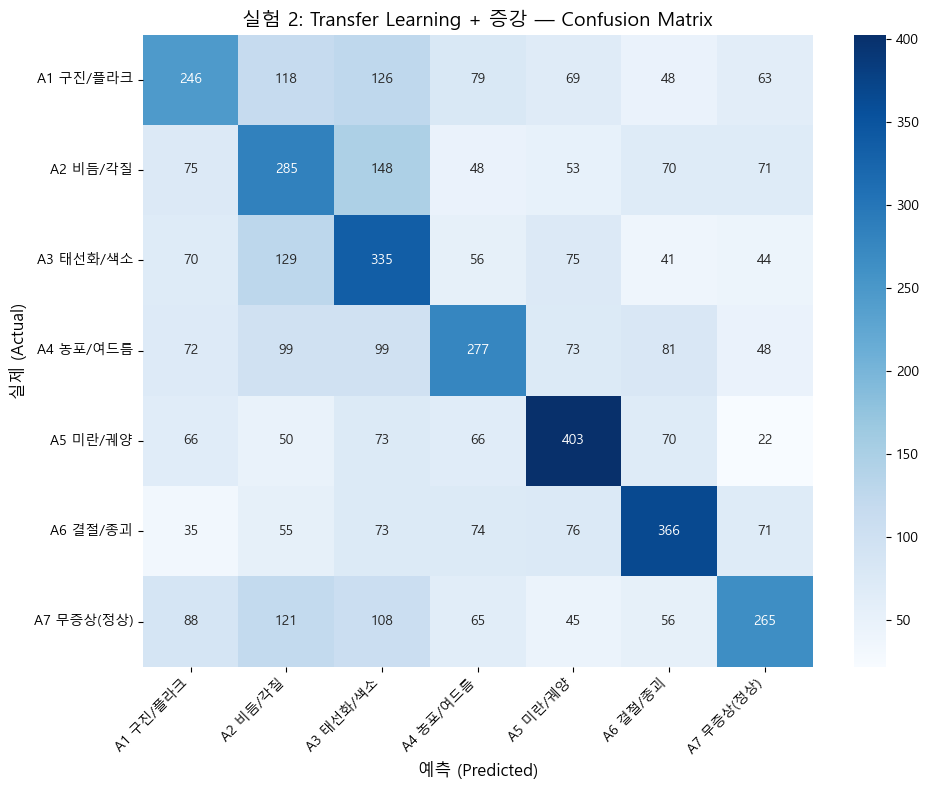

📊 혼동 행렬 저장 → ..\outputs\figures\exp2_confusion_matrix.png


In [43]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('예측 (Predicted)', fontsize=12)
ax.set_ylabel('실제 (Actual)', fontsize=12)
ax.set_title('실험 2: Transfer Learning + 증강 — Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(FIG_DIR / 'exp2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 혼동 행렬 저장 → {FIG_DIR / 'exp2_confusion_matrix.png'}")


## 11. 실험 2 결과 요약

이 결과를 실험 1, 실험 3과 비교하여 최종 모델을 선정합니다.


In [44]:
print("=" * 55)
print("📋 실험 2: Transfer Learning + 증강 결과 요약")
print("=" * 55)
print(f"모델 구조       : EfficientNetB0 (freeze) + Dense 분류층")
print(f"데이터 증강     : 적용 (회전, 반전, 밝기, 줌, 이동)")
print(f"Class Weight    : 없음")
print(f"학습률          : {LEARNING_RATE}")
print(f"학습 에폭       : {len(history.history['loss'])}회 (EarlyStopping 적용)")
print(f"최종 Train Loss : {history.history['loss'][-1]:.4f}")
print(f"최종 Train Acc  : {history.history['accuracy'][-1]:.4f}")
print(f"최종 Val Loss   : {history.history['val_loss'][-1]:.4f}")
print(f"최종 Val Acc    : {history.history['val_accuracy'][-1]:.4f}")
print(f"테스트 Loss     : {test_loss:.4f}")
print(f"테스트 Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"모델 저장 경로  : models/exp2_transfer.h5")
print("=" * 55)
print()
print("→ 다음: 실험 3 (Transfer Learning + 증강 + Class Weight)에서 불균형 보정 효과 확인")


📋 실험 2: Transfer Learning + 증강 결과 요약
모델 구조       : EfficientNetB0 (freeze) + Dense 분류층
데이터 증강     : 적용 (회전, 반전, 밝기, 줌, 이동)
Class Weight    : 없음
학습률          : 0.0001
학습 에폭       : 30회 (EarlyStopping 적용)
최종 Train Loss : 1.4314
최종 Train Acc  : 0.4697
최종 Val Loss   : 1.5051
최종 Val Acc    : 0.4290
테스트 Loss     : 1.5481
테스트 Accuracy : 0.4150 (41.5%)
모델 저장 경로  : models/exp2_transfer.h5

→ 다음: 실험 3 (Transfer Learning + 증강 + Class Weight)에서 불균형 보정 효과 확인
